<a href="https://colab.research.google.com/github/Pranathi38/Sentiment-Driven-Crypto-Trading-Analysis/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Libraries**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **Loading Datasets**

In [40]:
trades = pd.read_csv('trades.csv')          # your trader dataset
sentiment = pd.read_csv('sentiment.csv')    # fear/greed dataset

# **Preprocessing**


In [41]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(' ', '_')

In [62]:
trades['execution_price'] = pd.to_numeric(trades['execution_price'], errors='coerce')
trades['size_usd'] = pd.to_numeric(trades['size_usd'], errors='coerce')
trades['closed_pnl'] = pd.to_numeric(trades['closed_pnl'], errors='coerce')

trades['timestamp'] = pd.to_numeric(trades['timestamp'], errors='coerce')
trades['time'] = pd.to_datetime(trades['timestamp'], unit='ms', errors='coerce')

trades['date'] = trades['time'].dt.date

merged['classification'] = merged['classification'].replace({
    'Fear': 0,
    'Extreme Fear': 0,
    'Neutral': 1,
    'Greed': 2,
    'Extreme Greed': 2
})

/tmp/ipykernel_3193/3001371057.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged['classification'] = merged['classification'].replace({


In [46]:
# Trades
trades['timestamp'] = pd.to_numeric(trades['timestamp'], errors='coerce')
trades['time'] = pd.to_datetime(trades['timestamp'], unit='ms', errors='coerce')
trades['date'] = trades['time'].dt.date

# Sentiment
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
merged = trades.merge(sentiment, on='date', how='left')
print(merged.columns.tolist())

['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp_x', 'time', 'date', 'timestamp_y', 'value', 'classification']


In [47]:
print("Trades loaded:", 'trades' in locals())
print("Sentiment loaded:", 'sentiment' in locals())
print("Merged created:", 'merged' in locals())

Trades loaded: True
Sentiment loaded: True
Merged created: True


In [48]:
print(merged.head())

                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side     timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   closed_pnl  ...     order_id  crossed       fee      trade_id  \
0         0.0  ...  52017706630     

## **Analyzing Relationship**

In [52]:
merged['profit'] = pd.to_numeric(merged['closed_pnl'], errors='coerce')
merged['is_profit'] = (merged['profit'] > 0).astype(int)

In [53]:
print("\nAverage Profit by Sentiment:")
print(merged.groupby('classification')['profit'].mean())


Average Profit by Sentiment:
classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: profit, dtype: float64


In [54]:
print("\nWin Rate by Sentiment:")
print(merged.groupby('classification')['is_profit'].mean())


Win Rate by Sentiment:
classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: is_profit, dtype: float64


In [55]:
print("\nAverage Trade Size by Sentiment:")
print(merged.groupby('classification')['size_usd'].mean())


Average Trade Size by Sentiment:
classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: size_usd, dtype: float64


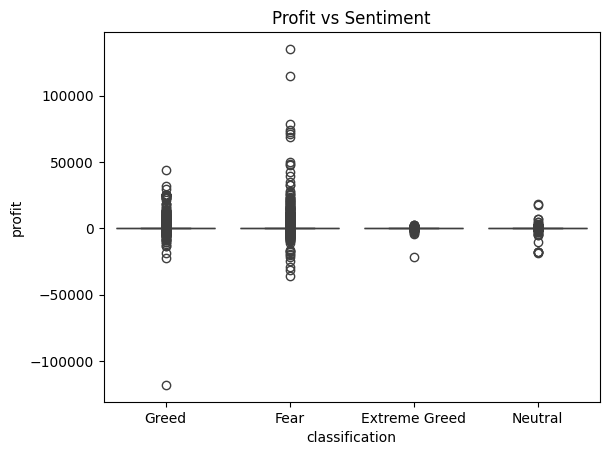

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='profit', data=merged)
plt.title("Profit vs Sentiment")
plt.show()

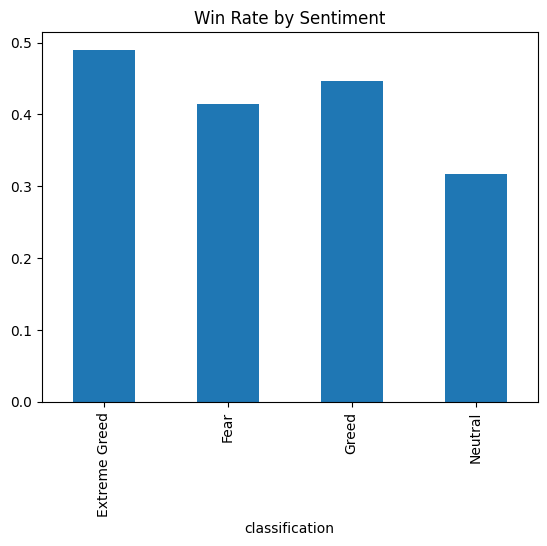

In [57]:
merged.groupby('classification')['is_profit'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

# **Training Model**

In [70]:
merged['is_buy'] = (merged['side'] == 'BUY').astype(int)
merged['hour'] = merged['time'].dt.hour

features = ['execution_price', 'size_usd', 'classification', 'hour']
X = merged[features].fillna(0)
y = merged['is_profit']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

print("Model training is successful")

Model traing is successful


## **Results**

In [65]:
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8065806604331873

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84     24796
           1       0.79      0.73      0.76     17449

    accuracy                           0.81     42245
   macro avg       0.80      0.80      0.80     42245
weighted avg       0.81      0.81      0.81     42245



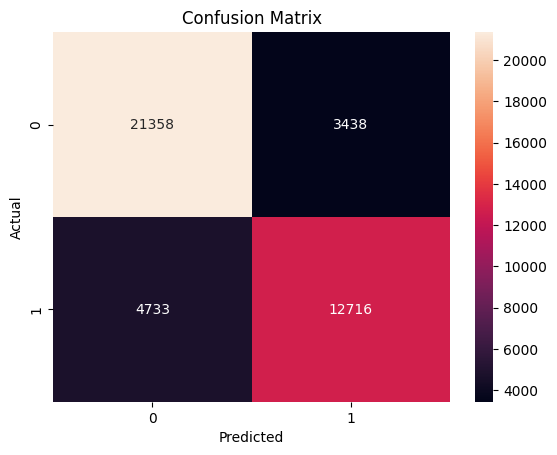

In [66]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

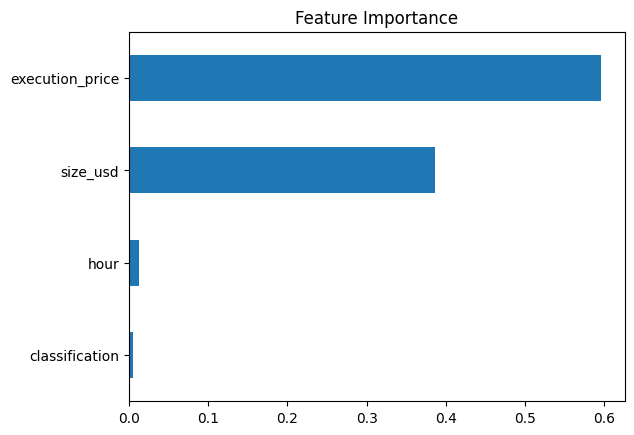

In [67]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()